# Segregation and heat

Bulding on [*Mobility patterns are associated with experienced income segregation in large US cities*](https://www.nature.com/articles/s41467-021-24899-8), we aim to understand how extreme heat relates to segregation in US cities.

* Can we measure segregation similar to [*Moro et al*](https://www.nature.com/articles/s41467-021-24899-8)?
* How does segregation evolve over time?
* How does extreme heat effect segragation?
* How does it effect place segregation vs personal segregation?
* How does POI segregation change when heat changes? Which POI categories unite in the face of climate change?


In [1]:
from datetime import datetime, timedelta, date
import math
from pathlib import Path

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import db
from wpp.segregation import data
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [20]:
def get_lf(
    con: DuckDBPyConnection,
    *,
    n_income_groups: int = 4,
    cbsafps: list[str] | None = None,
    limit: int | None = None,
) -> pl.LazyFrame:
    cbsa_str = "('" + "', '".join(cbsafps) + "')" if cbsafps else ""
    cbsa_snippet = f"AND CBSAFP in {cbsa_str}" if cbsafps else ""
    query = f"""
        WITH bg AS MATERIALIZED (
            SELECT
                GEOID, CBSAFP, CBSA_NAME, CBSA_POP_RANK,
                MEDIAN_HH_INCOME,
                NTILE({n_income_groups}) OVER (
                    PARTITION BY CBSAFP ORDER BY MEDIAN_HH_INCOME ASC
                ) AS INCOME_GROUP
            FROM block_groups_cbsa
            WHERE LSAD = 'M1'
              AND MEDIAN_HH_INCOME IS NOT NULL
              {cbsa_snippet}
        )
        SELECT
            bgh.CBSAFP AS CBSAFP,
            bgv.DATE_RANGE_START, bgv.DATE_RANGE_END, bgv.HOME_GEOID,
            bgv.ID_STORE, bgv.VISITOR_COUNTS, bgv.DIST,
            p.POI_GEOID, bgp.INCOME_GROUP AS POI_INCOME_GROUP,
            bgh.MEDIAN_HH_INCOME AS HOME_MEDIAN_HH_INCOME,
            bgh.INCOME_GROUP AS HOME_INCOME_GROUP
        FROM block_group_visits_enhanced bgv
        JOIN pois p ON bgv.ID_STORE = p.ID_STORE
        JOIN bg bgp ON p.POI_GEOID = bgp.GEOID
        JOIN bg bgh ON bgv.HOME_GEOID = bgh.GEOID
    """
    lf = con.sql(query).pl(lazy=True)
    return lf

In [31]:
pois = data.get_pois(con).lazy()
lf = get_lf(con, cbsafps=["33100", "31080", "16980"])

In [32]:
by = ["CBSAFP", "DATE_RANGE_START", "ID_STORE"]
visitor_distribution = (
    lf.filter(
        pl.col("HOME_INCOME_GROUP").is_not_null()
        & pl.col("VISITOR_COUNTS").is_not_null()
        & (pl.col("VISITOR_COUNTS") > 0)
    )
    .group_by([*by, "HOME_INCOME_GROUP"])
    .agg(pl.col("VISITOR_COUNTS").sum().alias("QUARTILE_VISITORS"))
    .with_columns(
        pl.col("QUARTILE_VISITORS").sum().over(by).alias("TOTAL_VISITORS")
    )
    .with_columns(
        (pl.col("QUARTILE_VISITORS") / pl.col("TOTAL_VISITORS")).alias("TAU")
    )
)

In [15]:
def l1_segregation(n_groups: int) -> pl.Expr:
    expected_share = 1 / n_groups
    normalization = n_groups / (2 * (n_groups - 1))

    return (normalization * (pl.col("TAU") - expected_share).abs().sum()).alias(
        "INCOME_SEGREGATION"
    )

In [33]:
segregation_expr = l1_segregation(4)
segregation = (
    visitor_distribution.group_by(by)
    .agg(
        pl.col("TOTAL_VISITORS").first(),
        segregation_expr,
    )
    .join(
        lf.group_by(by).agg(
            (
                (pl.col("DIST") * pl.col("VISITOR_COUNTS")).sum()
                / pl.col("VISITOR_COUNTS").sum()
            ).alias("DIST")
        ),
        on=by,
        how="left",
    )
)

In [34]:
agg = segregation.group_by("CBSAFP", "DATE_RANGE_START").agg(
    pl.col("TOTAL_VISITORS").sum(),
    pl.col("INCOME_SEGREGATION").mean().alias("AVG_INCOME_SEGREGATION"),
    ((pl.col("INCOME_SEGREGATION") * pl.col("TOTAL_VISITORS")).sum() / pl.col("TOTAL_VISITORS").sum()).alias("W_AVG_INCOME_SEGREGATION")
).collect()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

<Axes: xlabel='DATE_RANGE_START', ylabel='AVG_INCOME_SEGREGATION'>

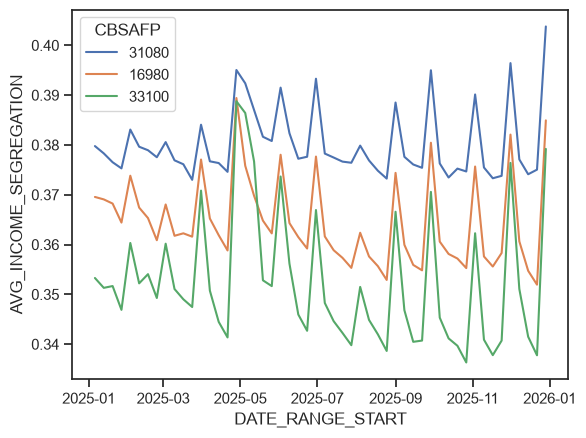

In [35]:
sns.lineplot(agg.to_pandas(), x="DATE_RANGE_START", y="AVG_INCOME_SEGREGATION", hue="CBSAFP")

In [36]:
cat_agg = segregation.join(pois, on="ID_STORE").group_by("TOP_CATEGORY", "DATE_RANGE_START").agg(
    pl.col("TOTAL_VISITORS").sum(),
    pl.col("INCOME_SEGREGATION").mean().alias("AVG_INCOME_SEGREGATION"),
    ((pl.col("INCOME_SEGREGATION") * pl.col("TOTAL_VISITORS")).sum() / pl.col("TOTAL_VISITORS").sum()).alias("W_AVG_INCOME_SEGREGATION")
).collect()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [43]:
top = cat_agg.group_by("TOP_CATEGORY").agg(pl.col("TOTAL_VISITORS").sum()).top_k(20, by="TOTAL_VISITORS")

<Axes: xlabel='DATE_RANGE_START', ylabel='AVG_INCOME_SEGREGATION'>

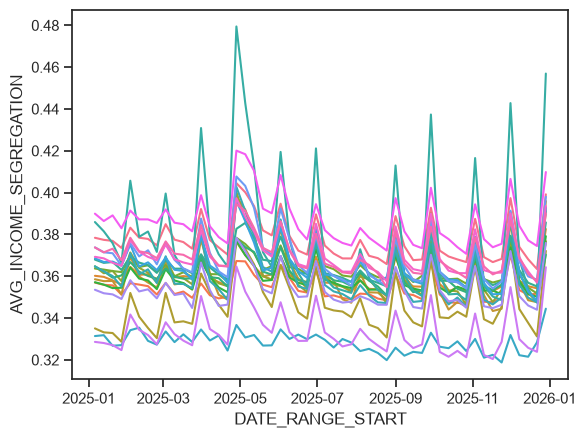

In [46]:
sns.lineplot(cat_agg.join(top, on="TOP_CATEGORY").to_pandas(), x="DATE_RANGE_START", y="AVG_INCOME_SEGREGATION", hue="TOP_CATEGORY", legend=False)

In [52]:
pois.filter(pl.col.TOP_CATEGORY == 'Traveler Accommodation').collect()

ID_STORE,POI_GEOID,CBSAFP,PERSISTENT_ID,BRAND,LOCATION_NAME,STREET_ADDRESS,CITY,REGION,ISO_COUNTRY_CODE,NAICS_CODE,TOP_CATEGORY,SUB_CATEGORY,OPEN_DATE,CLOSE_DATE,LONGITUDE,LATITUDE,GEOM,CELL_ID
str,str,str,str,str,str,str,str,str,str,str,str,str,date,date,f64,f64,ext[geoarrow.wkb],i64
"""11908410""","""060855017001""","""41940""","""A1_MAR""","""Marriott International""","""Marriott International, Inc.""","""301 South Market Street""","""San Jose""","""CA""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",2023-10-18,2038-01-01,-121.888356,37.330349,"b""\x01\x01\x00\x00\x00%\xcd\x1f\xd3\xdax^\xc0\x16\xa2C\xe0H\xaaB@""",424385
"""11908472""","""480291101002""","""41700""","""A1_MAR-AGRAPH""","""Autograph Collection Hotels""","""Autograph Collection Hotels""","""555 South Alamo Street""","""San Antonio""","""TX""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",2022-10-26,2038-01-01,-98.489114,29.419008,"b""\x01\x01\x00\x00\x00\x0e\xa2\xb5\xa2M\x9fX\xc0+\xc3\xb8\x1bDk=@""",691896
"""11908473""","""060750611012""","""41860""","""A1_MAR-AGRAPH""","""Autograph Collection Hotels""","""Autograph Collection Hotels""","""433 Clay Street""","""San Francisco""","""CA""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",2024-01-17,2038-01-01,-122.400684,37.794708,"b""\x01\x01\x00\x00\x00\xf3\x01\x81\xce\xa4\x99^\xc0N\xef\xe2\xfd\xb8\xe5B@""",408917
"""11908489""","""481130204022""","""19100""","""A1_HLT-TAP""","""Tapestry Collection by Hilton""","""Tapestry Collection by Hilton""","""1011 South Akard Street""","""Dallas""","""TX""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",2023-10-27,2038-01-01,-96.795513,32.772818,"b""\x01\x01\x00\x00\x00\xca\xc3B\xad\xe92X\xc04\x9fs\xb7\xebb@@""",578132
"""11908490""","""240037512002""","""12580""","""A1_H-HH""","""Hyatt House""","""Hyatt House""","""857 Elkridge Landing Road""","""Linthicum Heights""","""MD""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",2024-01-31,2038-01-01,-76.688981,39.198976,"b""\x01\x01\x00\x00\x00#\x83\xdcE\x18,S\xc0.X\xaa\x0bx\x99C@""",362244
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""9920907""","""530630032001""","""44060""","""A1_NAICS-721110""","""Hotels (except Casino Hotels) …","""Hotels (except Casino Hotels) …","""110 E 4Th Ave""","""Spokane""","""WA""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",1970-01-01,2038-01-01,-117.409256,47.651707,"b""\x01\x01\x00\x00\x00\x10L\x7f@1Z]\xc0\xc3\x8a\x09\x20k\xd3G@""",76052
"""9920919""","""360610113001""","""35620""","""A1_NAICS-721110""","""Hotels (except Casino Hotels) …","""Hotels (except Casino Hotels) …","""1466 Broadway""","""New York""","""NY""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",1970-01-01,2038-01-01,-73.986267,40.755581,"b""\x01\x01\x00\x00\x00\xbb\xe7\x0a\x00\x1f\x7fR\xc0\xba}\xfb\xdf\xb6`D@""",310324
"""9920920""","""481677214021""","""26420""","""A1_NAICS-721110""","""Hotels (except Casino Hotels) …","""Hotels (except Casino Hotels) …","""909 Marina Bay Dr""","""Kemah""","""TX""","""US""","""721110""","""Traveler Accommodation""","""Hotels (except Casino Hotels) …",1970-01-01,2038-01-01,-95.031067,29.5404,"b""\x01\x01\x00\x00\x00=\xdf\x05\x00\xfd\xc1W\xc0\x80\xc5\xd0\xa0W\x8a=@""",687764


In [49]:
cat_agg.join(top, on="TOP_CATEGORY").filter(pl.col.AVG_INCOME_SEGREGATION > 0.45)

TOP_CATEGORY,DATE_RANGE_START,TOTAL_VISITORS,AVG_INCOME_SEGREGATION,W_AVG_INCOME_SEGREGATION,TOTAL_VISITORS_right
str,datetime[μs],i32,f64,f64,i32
"""Traveler Accommodation""",2025-04-28 00:00:00,20491318,0.479436,0.382582,1011125454
"""Traveler Accommodation""",2025-12-29 00:00:00,19093175,0.456914,0.361359,1011125454


In [14]:
def write_parquet(
    con: DuckDBPyConnection,
    out_dir: str | Path,
    *,
    n_income_groups: int = 4,
    cbsafps: list[str] | None = None,
    compression: str = "zstd",
) -> None:
    cbsa_snippet = ""
    if cbsafps:
        cbsa_str = ", ".join(f"'{c}'" for c in cbsafps)
        cbsa_snippet = f"AND CBSAFP IN ({cbsa_str})"

    query = f"""
        WITH bg AS MATERIALIZED (
            SELECT
                GEOID, CBSAFP, CBSA_NAME, CBSA_POP_RANK,
                MEDIAN_HH_INCOME,
                NTILE({n_income_groups}) OVER (
                    PARTITION BY CBSAFP ORDER BY MEDIAN_HH_INCOME ASC
                ) AS INCOME_GROUP
            FROM block_groups_cbsa
            WHERE LSAD = 'M1'
              AND MEDIAN_HH_INCOME IS NOT NULL
              {cbsa_snippet}
        )
        SELECT
            bgh.CBSAFP AS CBSAFP,
            bgv.DATE_RANGE_START, bgv.DATE_RANGE_END, bgv.HOME_GEOID,
            bgv.ID_STORE, bgv.VISITOR_COUNTS, bgv.DIST,
            p.POI_GEOID, bgp.INCOME_GROUP AS POI_INCOME_GROUP,
            bgh.MEDIAN_HH_INCOME AS HOME_MEDIAN_HH_INCOME,
            bgh.INCOME_GROUP AS HOME_INCOME_GROUP
        FROM block_group_visits_enhanced bgv
        JOIN pois p ON bgv.ID_STORE = p.ID_STORE
        JOIN bg bgp ON p.POI_GEOID = bgp.GEOID
        JOIN bg bgh ON bgv.HOME_GEOID = bgh.GEOID
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    con.execute(f"""
        COPY ({query}) TO '{out_dir}' (
            FORMAT PARQUET,
            PARTITION_BY (CBSAFP),
            COMPRESSION {compression},
            OVERWRITE_OR_IGNORE
        )
    """)

In [15]:
parquet_dir = root / "data" / "materialized"
write_parquet(con, parquet_dir, cbsafps=["33100", "31080"])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))